# CaII flush

- 2024.06.13k.i. 

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
#warnings.simplefilter('ignore', DeprecationWarning)

C:\Users\ichim\AppData\Local\Temp\ipykernel_22136\40545689.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util.HelpUtil import help_
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
from spectra.Atomic import Hydrogen
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel

## Setup atomic model and Solar spectrum

In [3]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )  ; H_nam ='H'
atom_H, wMesh_H, path_dict_H = Atom.init_Atom_(conf_path , is_hydrogen=True)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_I-II-III.conf" ) ; Ca_nam ='Ca_I-II-III' 
#conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_II.conf" ) ; Ca_nam ='Ca_II'
atom_Ca, wMesh_Ca, path_dict_ca = Atom.init_Atom_(conf_path , is_hydrogen=False)

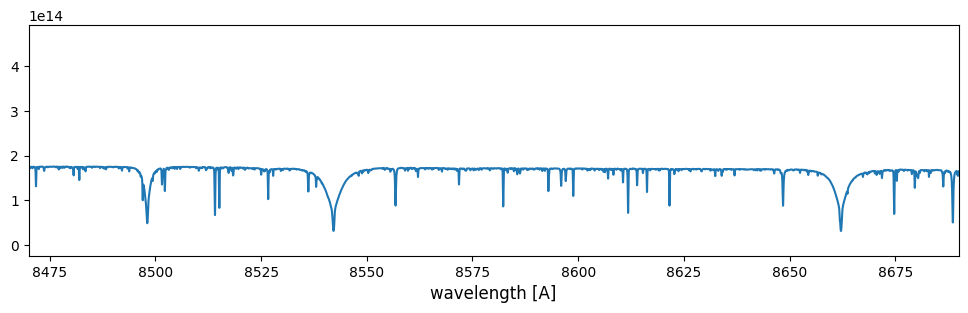

In [31]:
#  prepare solar radiation spectrum
import copy

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vt=5.E5)
solar_spec_H  = Radiation.init_Radiation_()
solar_spec_Ca = Radiation.init_Radiation_()

wls = solar_spec_H.solar[0,:]*1E8         
wla = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = solar_spec_H.solar[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

#  for photo-excitation, mean intensity gets half of the backgroud solar spectrum
#  (paired backRad/PI_intensity scaling collapses to a single solar scaling under the new API)
solar_spec_H.solar[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_Ca.solar[1,:] *= 0.5           # solar spectrum mean intensity    "    [erg/cm^3/s/str]

#  for sunspot 
ispot = 0.1
solar_spec_H.solar[1,:] *= ispot          
solar_spec_Ca.solar[1,:] *= ispot         

solar_spec_H0 = copy.deepcopy(solar_spec_H)
solar_spec_Ca0 = copy.deepcopy(solar_spec_Ca)

fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wla, Isolar)
#ax.set_xlim(1000, 11000)
ax.set_xlim(8470, 8690)
#ax.set_xlim(10820, 10840) ; ax.set_ylim(0,1.2e14)
#ax.set_yscale("log") ; ax.set_ylim(1e7,1e15)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

In [30]:
help_(solar_spec_Ca)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
Radiation
|- backRad                 ndarray                              s: (2, 3754678)
|- PI_intensity            ndarray                              s: (44, 41)


## Calc. SE and line profiles of CaII for a [$T_e,n_H$]

In [32]:
# import CloudModel from spectra.Function.SlabModel

Te = 7000.
Nh = 1*1e11
Ne = 2e10
Vt = 5e5            #   cm/s
depth = 500 * 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # CaII lines intensity


------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
CloudModel_Container
|- w0                      ndarray                              s: (471,)
|- tau_max                 ndarray                              s: (471,)
|- Ibar                    ndarray                              s: (471,)
|- Src                     ndarray                              s: (471,)
|- tau_1D                  ndarray                              s: (19865,)
|- prof_1D                 ndarray                              s: (19865,)
|- wl_1D                   ndarray                              s: (19865,)
|- Line_mesh_idxs          ndarray                              s: (471, 2)


Text(0.5, 0, 'wavelength [A]')

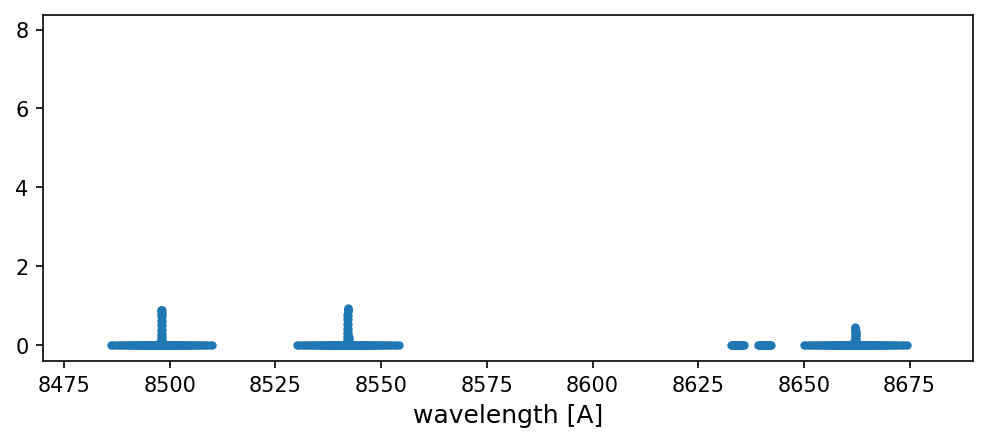

In [33]:
help_(lCa)
wlc = BasicP.vacuum_to_air_(lCa.wl_1D*1e8,'AA')   # wavelength in air for CaII [A])

fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(wlc,lCa.tau_1D,'.')
ax.set_xlim(8470, 8690)
ax.set_xlabel("wavelength [A]", fontsize=12)


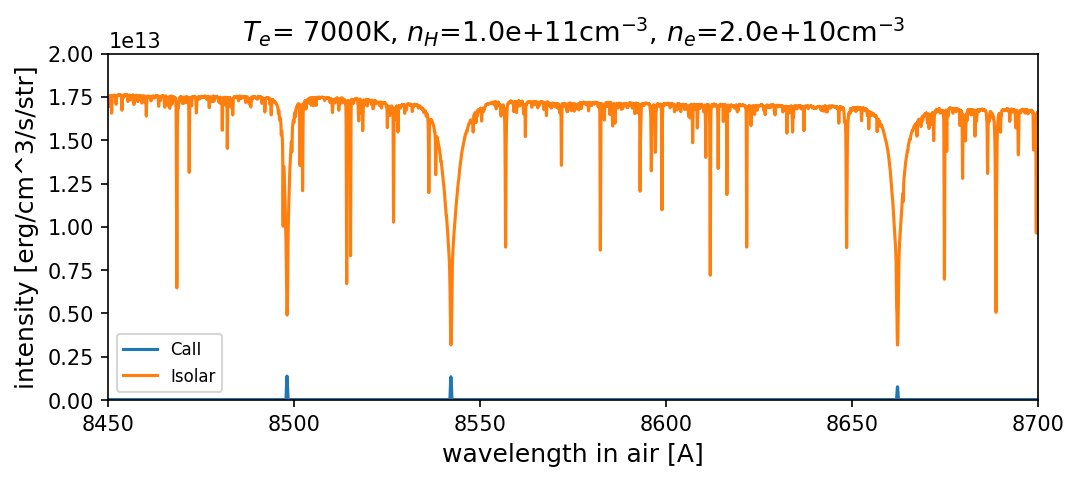

In [36]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)

#wlh = BasicP.vacuum_to_air_(lH.wl_1D*1e8,'AA')   # wavelength in air for H [A])
wlc = BasicP.vacuum_to_air_(lCa.wl_1D*1e8,'AA')   # wavelength in air for CaII [A])
#ax.plot(wlh,lH.prof_1D,label='H')
ax.plot(wlc,lCa.prof_1D,label='CaII')
ax.plot(wla,Isolar*ispot,label='Isolar')

#ax.set_xlim(3000, 11000)
ax.set_xlim(8450, 8700)
#ax.set_yscale("log")
ax.set_ylim(0, 2e13)
ax.set_xlabel("wavelength in air [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$, $n_e$={2:5.1e}cm$^{{-3}}$".format(Te, Nh, Ne),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

## Get line profile prom l. structure with cloud model
###  $\qquad$    $I_{out} = I_{back} e^{-\tau} + S (1-e^{-\tau})$

In [37]:
def wlarr(wl00,vmax,dv):
# return wl[:] around wl00 in A,  vmax, dv  in km/s

    dw = dv/Cst.c_*wl00*1e5
    wmin = wl00 - dw*vmax/dv
    wmax = wl00 + dw*vmax/dv
    nw = 2*int(vmax/dv) +1
    #nw = int((wmax-wmin)/dw) + 1
    wl = np.linspace(wmin,wmax,nw)
    return wl

#-------------------------------------------------------------
def get_lprof(l, wl, Ibk=0., air=1):
#-------------------------------------------------------------
# extract line profile in a wl interval from l-structure 
# wl[:]   -- wavelength array including line of interest in A 
# Ibk[:]  -- background intensity
# air     -- if 1, wl in air is used

    nw = wl.size
    profe = np.zeros(nw)
    tau = np.zeros(nw)

    if air == 1:
        wl1D = BasicP.vacuum_to_air_(l.wl_1D*1e8,'AA') 
        w0 = BasicP.vacuum_to_air_(l.w0 *1e8,'AA')  # in A
        print('wl in air')
    else:
        wl1D = l.wl_1D*1e8
        w0 = l.w0 *1e8  # in A
    jj = np.where((w0 > min(wl)) & (w0 < max(wl)))[0]

    for j in jj:
        idx1 = l.Line_mesh_idxs[j,0] 
        idx2 = l.Line_mesh_idxs[j,1]
        tau1 = np.interp(wl, wl1D[idx1:idx2], l.tau_1D[idx1:idx2])
        prof1 = l.Src[j] * (1.-np.exp(-tau1))
        #print('Ic, Src=',Ic,l.Src[j])
        tau += tau1
        profe += prof1
        
    prof = Ibk*np.exp(-tau) + profe
    
    ldat = {
        "intens": prof,
        "tau": tau,
        "src": max(l.Src[jj]),
    }
    
    return ldat


In [38]:
from dataclasses import dataclass as _dataclass
@_dataclass(**STRUCT_KWGS_UNFROZEN)
#-------------------------------------------------------------
class Line_Container:
#-------------------------------------------------------------
    wl0                : T_ARRAY     # 1d, (nLine,) wavelength, [cm]
    wl                 : T_ARRAY     # 1d, (nLine,), intensity profile integrated over wavelength, [erg/cm^2/Sr/s]
    src                : T_ARRAY     # 1d, (nLine,), maximum optical depth, [-]
    tau                : T_ARRAY     # 1d, (sum_of_line_wavelength_mesh,), optical thickness profile, [-]
    prof               : T_ARRAY     # 1d, (sum_of_line_wavelength_mesh,), out intensity profile, [erg/cm^2/Sr/cm/s]


#-------------------------------------------------------------
def get_line(l, wl00, air=1):
#-------------------------------------------------------------
# extract 1 line from l-structure 
# wl00   -- central wavelength in A 
    
    if air == 1:
        wl1D = BasicP.vacuum_to_air_(l.wl_1D*1e8,'AA') 
        w0 = BasicP.vacuum_to_air_(l.w0 *1e8,'AA')  # in A
        #print('wl in air')
    else:
        wl1D = l.wl_1D*1e8
        w0 = l.w0 *1e8  # in A
    j = np.argmin(np.abs(wl00-w0))
    idx1 = l.Line_mesh_idxs[j,0] 
    idx2 = l.Line_mesh_idxs[j,1]
    wl0 = w0[j]
    src = l.Src[j]
    wl = wl1D[idx1:idx2]
    tau = l.tau_1D[idx1:idx2]
    prof = l.prof_1D[idx1:idx2]

    l1 = Line_Container(
        wl0 = wl0,
        wl = wl,
        src = src,
        tau = tau,
        prof = prof,
    )
    return(l1)

 

8498.031485390657
8542.095409113488
8662.149054841533


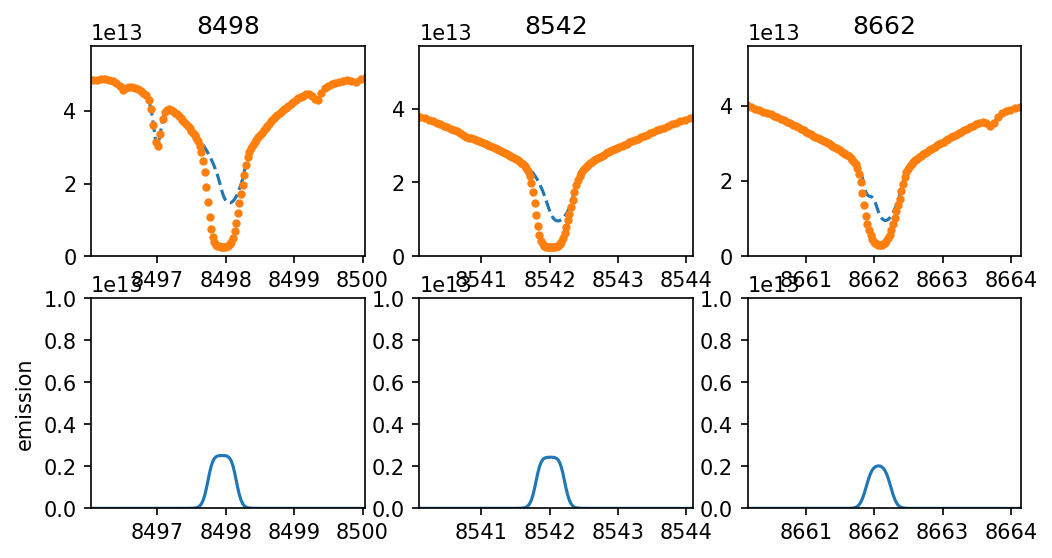

In [40]:
Te = 7000.
Nh = 5*1e11
#Ne = 2e10
Vd_sun = -3e5
Vd_obs = 3e5
Vt = 5e5            #   cm/s
depth = 500. * 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd_sun=Vd_sun, Vd_obs=Vd_obs, Vt=Vt)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # CaII lines intensity

#help_(lCa)
wl00 = [8498, 8542, 8662]
dw = 2.
nl = len(wl00)

fig, axs = plt.subplots(2,3, figsize=(8,4), dpi=150)#, sharey=True)
for i in range(0,nl):
    wl0 = wl00[i]
    l1 = get_line(lCa,wl0)
    print(l1.wl0)
    wl = l1.wl
    tau = l1.tau
    profe = l1.src * (1.-np.exp(-tau))
    Ibk = np.interp(wl,wla,Isolar) *0.3
    prof = Ibk*np.exp(-tau) + profe
    ax = axs[0,i]
    ax.plot(wl,Ibk,'--')
    ax.plot(wl,prof,'.')
    ax.set_xlim(l1.wl0-dw,l1.wl0+dw)
    ax.set_ylim(0,np.max(prof)*1.1)
    ax.set_xlabel('wl [A]')
    ax.set_title(wl00[i])
    ax = axs[1,i]
    #ax.plot(wl,tau)#,'.')
    ax.plot(wl,profe)#,'.')
    ax.set_xlim(l1.wl0-dw,l1.wl0+dw)
    #ax.set_ylim(0,2)
    ax.set_ylim(0,1e13)
    if i==0:
        #ax.set_ylabel('optical thickness')
        ax.set_ylabel('emission')
    



In [12]:
#line_list(atom_Ca)
help_(lCa)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
CloudModel_Container
|- w0                      ndarray                              s: (471,)
|- tau_max                 ndarray                              s: (471,)
|- Ibar                    ndarray                              s: (471,)
|- Src                     ndarray                              s: (471,)
|- tau_1D                  ndarray                              s: (19865,)
|- prof_1D                 ndarray                              s: (19865,)
|- wl_1D                   ndarray                              s: (19865,)
|- Line_mesh_idxs          ndarray                              s: (471, 2)


In [53]:
Te = 10000.
Nh = 1*1e11
NNh = 100
Nhs = np.logspace(10,12,NNh)
#Ne = 2e10
Vd_sun = -3.e5             #   cm-3
Vd_obs = 3.e5
Vt = 7e5            #   cm/s
depth = 500. * 1.E5 #   km *1e5

wl00 = [8498, 8542, 8662]
dw = 2.
nl = len(wl00)

tau = np.zeros([NNh,nl])
intens = np.zeros([NNh,nl])

for i in range(0,NNh):
    Nh = Nhs[i]
    print(i, end='\r')
    slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd_sun=Vd_sun, Vd_obs=Vd_obs, Vt=Vt)     # slab 
    SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
    lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
    SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
    lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # CaII lines intensity
    
    for l in range(0,nl):
        wl0 = wl00[l]
        l1 = get_line(lCa,wl0)
        wl = l1.wl
        tau[i,l] = np.max(l1.tau)
        #intens[i,l] = np.max(l1.prof)
        intens[i,l] = l1.src * (1.-np.exp(-tau[i,l]))


In [20]:
wl00

[8498, 8542, 8662]

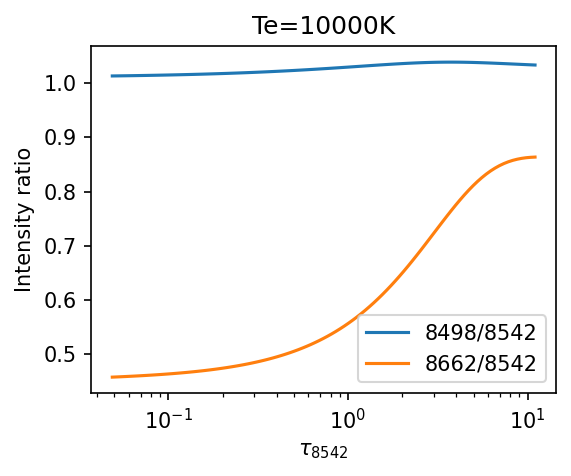

In [54]:
fig, ax = plt.subplots(1,1, figsize=(4,3), dpi=150)

r8498 = intens[:,0]/intens[:,1]
r8662 = intens[:,2]/intens[:,1]
tau854 = tau[:,1]
ax.plot(tau854,r8498, label='8498/8542')
ax.plot(tau854,r8662, label='8662/8542')
ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_xlabel(r"$\tau_{8542}$")
ax.set_ylabel("Intensity ratio")
ax.set_title(f'Te={Te:5.0f}K')

plt.legend(loc='lower right')
plt.show()

In [ ]:


fig, axs = plt.subplots(2,3, figsize=(8,4), dpi=150)#, sharey=True)
for i in range(0,nl):
    wl0 = wl00[i]
    l1 = get_line(lCa,wl0)
    print(l1.wl0)
    wl = l1.wl
    tau = l1.tau
    profe = l1.src * (1.-np.exp(-tau))
    Ibk = np.interp(wl,wla,Isolar) *0.3
    prof = Ibk*np.exp(-tau) + profe
    ax = axs[0,i]
    ax.plot(wl,Ibk,'--')
    ax.plot(wl,prof,'.')
    ax.set_xlim(l1.wl0-dw,l1.wl0+dw)
    ax.set_ylim(0,np.max(prof)*1.1)
    ax.set_xlabel('wl [A]')
    ax.set_title(wl00[i])
    ax = axs[1,i]
    ax.plot(wl,tau)#,'.')
    ax.set_xlim(l1.wl0-dw,l1.wl0+dw)
    ax.set_ylim(0,2)
    if i==0:
        ax.set_ylabel('optical thickness')
    



wl in air


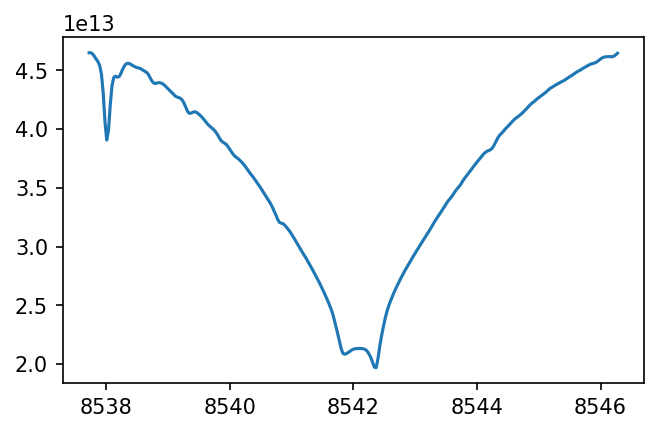

In [13]:
Te = 10000.
Nh = 1*1e11
Ne = 2e10
Vt = 5e5            #   cm/s
depth = 0.5E4 * 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vt=Vt)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # CaII lines intensity

vmax = 150. ; dv = 1.  # km/s
wl00 = 8542.

wl = wlarr(wl00,vmax, dv)  #  wavelength in air

Ibk = np.interp(wl,wla,Isolar)
lprof = get_lprof(lCa, wl, Ibk=Ibk*0.3)

fig, ax = plt.subplots(1,1, figsize=(5,3), dpi=150)
ax.plot(wl,lprof["intens"])

In [41]:
lCa.w0

array([6.59721832e-05, 6.57459343e-05, 6.52914305e-05, 4.91754177e-05,
       4.91418270e-05, 4.90893830e-05, 4.57673480e-05, 4.22791709e-05,
       3.17062724e-05, 3.00144637e-05, 2.79183628e-05, 2.79053519e-05,
       2.73562215e-05, 2.72244993e-05, 2.68108780e-05, 2.64913270e-05,
       2.64887512e-05, 2.64848356e-05, 1.91709332e-02, 6.32743426e-03,
       1.93144905e-04, 1.92627748e-04, 1.91824445e-04, 1.49438085e-04,
       1.17724550e-04, 6.10441096e-05, 5.50680001e-05, 4.84007998e-05,
       4.83617081e-05, 4.67358463e-05, 4.63526972e-05, 4.51663229e-05,
       4.42667876e-05, 4.42595960e-05, 4.42486653e-05, 9.44468638e-03,
       1.95110621e-04, 1.94582899e-04, 1.93763241e-04, 1.50612111e-04,
       1.18451938e-04, 6.12391073e-05, 5.52266372e-05, 4.85233064e-05,
       4.84840167e-05, 4.68500597e-05, 4.64650434e-05, 4.52729851e-05,
       4.43692387e-05, 4.43620138e-05, 4.43510324e-05, 1.99226286e-04,
       1.98676097e-04, 1.97821667e-04, 1.53052807e-04, 1.19956388e-04,
      